In [62]:
import rasterio
import xarray as xr
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt


In [63]:
# import raster files
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'
msa_ds=gpd.read_file(msa_file)



### Pixel count for each range, original and downscaled NEE

Original NEE is all in range (-10, 10) 
while downscaled NEE has extreme values and more pixels closer to 0

In [142]:
# get raster value count by range for original NEE

year_month = '200101'
downscaled_nee_file_path = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'

variable = 'NEE'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values
valid_values = original_nee[~np.isnan(original_nee)]

counts = {}
bounds = [(-10000000, -100), (-100, -10), (-10, -1), (-1, 0), (0, 0.00001), (0.00001, 1), (1, 10), (10, 100), (100, 10000000)] 
for lower, upper in bounds:
    counts[(lower, upper)] = np.sum((valid_values >= lower) & (valid_values < upper))
counts

{(-10000000, -100): np.int64(0),
 (-100, -10): np.int64(0),
 (-10, -1): np.int64(264058),
 (-1, 0): np.int64(446485),
 (0, 1e-05): np.int64(16),
 (1e-05, 1): np.int64(1044471),
 (1, 10): np.int64(2215),
 (10, 100): np.int64(0),
 (100, 10000000): np.int64(0)}

In [143]:
# get raster value count by range for downscaled NEE
with rasterio.open(downscaled_nee_file_path) as src:
    raster_data = src.read(1)  # Read the first band
    raster_data = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

valid_values = raster_data[~np.isnan(raster_data)]
counts = {}
bounds = [(-10000000, -100), (-100, -10), (-10, -1), (-1, 0), (0, 0.00001), (0.00001, 1), (1, 10), (10, 100), (100, 10000000)] 
for lower, upper in bounds:
    counts[(lower, upper)] = np.sum((valid_values >= lower) & (valid_values < upper))

counts

{(-10000000, -100): np.int64(275),
 (-100, -10): np.int64(2334),
 (-10, -1): np.int64(91136),
 (-1, 0): np.int64(8559144),
 (0, 1e-05): np.int64(9195694),
 (1e-05, 1): np.int64(19534415),
 (1, 10): np.int64(1101530),
 (10, 100): np.int64(20103),
 (100, 10000000): np.int64(614)}

### Histogram of pixel count / pixel number, for downscaled and original NEE comparison

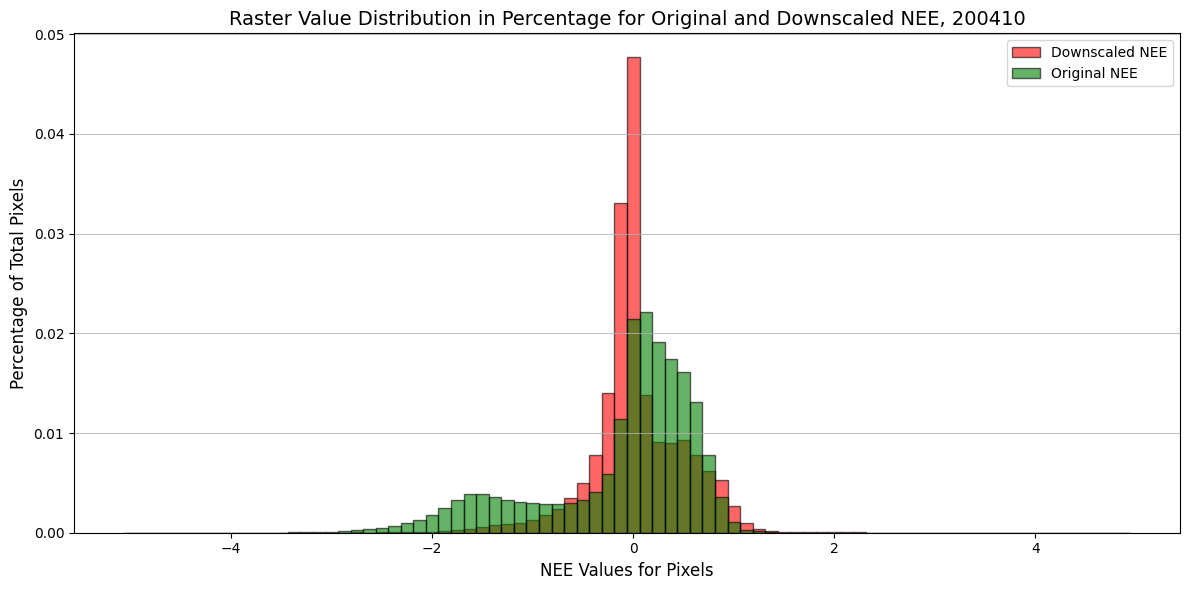

In [175]:
# Plot the pixel count / pixel number histograms
bins=80
year_month = '200410'
title=f"Raster Value Distribution in Percentage for Original and Downscaled NEE, {year_month}"
x_min = -5
x_max = 5


downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(downscaled_nee == src.nodata, np.nan, downscaled_nee)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

# Calculate total number of pixels in the raster
total_pixels_downscaled = downscaled_nee.size  # Total pixels (rows * cols)
total_pixels_original = original_nee.size

# Compute histograms
hist_downscaled, bin_edges = np.histogram(valid_downscaled, bins=bins, range=(x_min, x_max))
hist_original, _ = np.histogram(valid_original, bins=bins, range=(x_min, x_max))

# Convert counts to percentages
hist_downscaled_percentage = hist_downscaled / total_pixels_downscaled
hist_original_percentage = hist_original / total_pixels_original

# Plot histogram with correct percentages
plt.figure(figsize=(12, 6))
plt.bar(bin_edges[:-1], hist_downscaled_percentage, width=np.diff(bin_edges), color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.bar(bin_edges[:-1], hist_original_percentage, width=np.diff(bin_edges), color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.title(title, fontsize=14)
plt.xlabel('NEE Values for Pixels', fontsize=12)
plt.ylabel('Percentage of Total Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


### Histogram of NEE mean for each MSA


In [174]:
# reproject MSA file from albert equal area to NEE crs (EPSG:4326)
gpp_file = f'../gis/GPP_monthly_mean/gpp_200101.tif'

with rasterio.open(gpp_file) as gpp_dstrd:
    gpp_crs = gpp_dstrd.crs
nee_crs = gpp_crs

msa_gdf_crsaea = gpd.read_file(msa_file)
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(nee_crs)

In [178]:
# Compute mean NEE for each MSA
downscaled_means = []
original_means = []

msa_gdf = msa_gdf_crs4326
for _, row in msa_gdf_crs4326.iterrows():
    msa_geometry = [row['geometry']]
    
    # Mask the raster with the MSA boundary for downscaled NEE
    with rasterio.open(original_nee_file_path) as src:
        out_downscaled, _ = mask(src, msa_geometry, crop=True, nodata=np.nan)
        out_downscaled = out_downscaled[0]
        
    if np.isnan(out_downscaled).all():
        downscaled_means.append(np.nan)
    else:
        downscaled_means.append(np.nanmean(out_downscaled))
    
    # Mask the raster with the MSA boundary for original NEE
    with rasterio.open(downscaled_nee_file) as src:
        out_original, _ = mask(src, msa_geometry, crop=True, nodata=np.nan)
        out_original = out_original[0]
        
    if np.isnan(out_original).all():
        original_means.append(np.nan)
    else:
        original_means.append(np.nanmean(out_original))

# Add computed values to the GeoDataFrame
msa_gdf['downscaled_nee_mean'] = downscaled_means
msa_gdf['original_nee_mean'] = original_means

# Plot histogram for NEE mean of each MSA
plt.figure(figsize=(12, 6))

plt.hist(msa_gdf['downscaled_nee_mean'].dropna(), bins=30, alpha=0.6, color='red', edgecolor='black', label='Downscaled NEE')
plt.hist(msa_gdf['original_nee_mean'].dropna(), bins=30, alpha=0.6, color='green', edgecolor='black', label='Original NEE')

plt.xlabel('Mean NEE')
plt.ylabel('Frequency')
plt.title('Histogram of NEE Mean Values for Each MSA')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Create a pandas DataFrame for better visibility
msa_stats_df = pd.DataFrame({
    'MSA_Name': msa_gdf['NAME'],
    'Downscaled_NEE_Mean': msa_gdf['downscaled_nee_mean'],
    'Original_NEE_Mean': msa_gdf['original_nee_mean']
})

C:\Users\qifanw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


ValueError: Input shapes do not overlap raster.

### NEE/GPP ratio distribution

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask

year_month = '200601'
year = year_month[:4]
month = year_month[4:]
downscaled_ratio_file = f'../gis/output/downscaleRatio/ratio_us_{year}_{month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'

# Load the MSA shapefile
msa_gdf = gpd.read_file(msa_file)

# Open the raster file
with rasterio.open(downscaled_ratio_file) as src:
    ratio = src.read(1)  # Read the first band
    ratio = np.where(ratio == src.nodata, np.nan, ratio)  # Replace nodata values with NaN
    raster_meta = src.meta.copy()

# Ensure CRS match between shapefile and raster
msa_gdf = msa_gdf.to_crs(raster_meta['crs'])

# Function to compute mean for each MSA and store it in the GeoDataFrame
mean_ratios = []

for index, row in msa_gdf.iterrows():
    msa_geometry = [row['geometry']]  # Extract geometry
    with rasterio.open(downscaled_ratio_file) as src:
        out_image, out_transform = mask(src, msa_geometry, crop=True, nodata=np.nan)
        out_image = out_image[0]  # Extract the first band

    # Remove NaN values and calculate the mean
    valid_pixels = out_image[~np.isnan(out_image)]
    mean_ratio = np.mean(valid_pixels) if valid_pixels.size > 0 else np.nan
    mean_ratios.append(mean_ratio)

# Add mean ratio values to the GeoDataFrame
msa_gdf['mean_ratio'] = mean_ratios

# Plot the map with the mean ratios
plt.figure(figsize=(20, 12))
msa_gdf.plot(column='mean_ratio', cmap='RdBu', legend=True, edgecolor='black', linewidth=0.5)
plt.title(f'Mean Ratio of Each MSA, {year_month}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

import pandas as pd
msa_stats_df = pd.DataFrame({
    'MSA_Name': msa_gdf['NAME'],  # Replace 'NAME' with the actual column for MSA names
    'Mean_Ratio': msa_gdf['mean_ratio']
})
msa_stats_df.describe()
print(f'MSAswith lowest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=True).head(10))
print(f'MSAswith highest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=False).head(10))

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_15940\1097877900.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


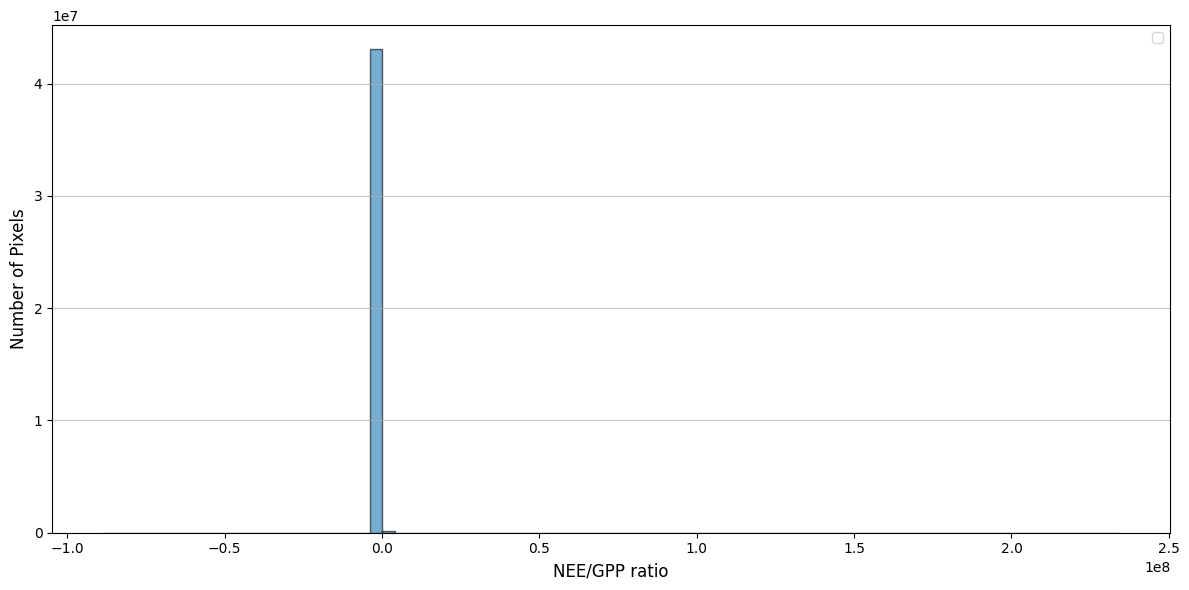

In [156]:
# Plot the pixel count / pixel number histograms
bins=80
year_month = '200201'
title=f"Ratio Distribution, {year_month}"

downscaled_ratio_file = f'../gis/output/downscaleRatio/ratio_US_{year_month}.tif'

with rasterio.open(downscaled_ratio_file) as src:
    ratio = src.read(1)  # Read the first band
    ratio = np.where(ratio == src.nodata, np.nan, ratio)  # Replace nodata values with NaN

valid_ratio = ratio[(~np.isnan(ratio))]

# Plot histogram with correct percentages
plt.figure(figsize=(12, 6))

x_min = -1
x_max = 2
plt.hist(valid_ratio, bins=bins, alpha=0.6, edgecolor='black')

plt.xlabel('NEE/GPP ratio', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_15940\65696357.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


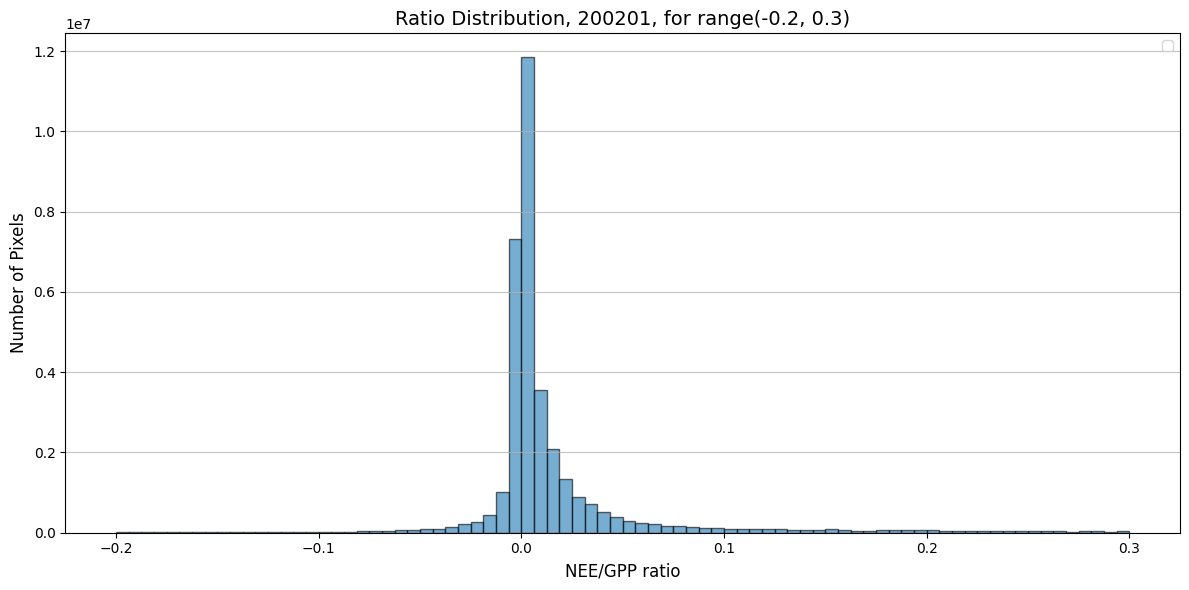

In [157]:
x_min = -0.2
x_max = 0.3
plt.figure(figsize=(12, 6))
plt.hist(valid_ratio, bins=bins, range=(x_min, x_max), alpha=0.6, edgecolor='black')

plt.title(title + f', for range({x_min}, {x_max})', fontsize=14)
plt.xlabel('NEE/GPP ratio', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Mean ratio for each MSA

<Figure size 2000x1200 with 0 Axes>

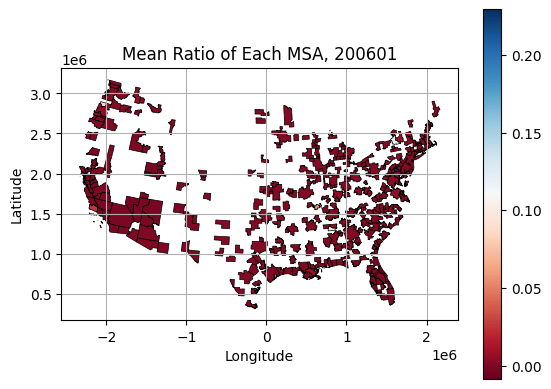

MSAswith lowest mean NEE/GPP ratio, 200601:
                                    MSA_Name  Mean_Ratio
280   Deltona-Daytona Beach-Ormond Beach, FL   -0.008674
316                      Provo-Orem-Lehi, UT   -0.006687
233       Los Angeles-Long Beach-Anaheim, CA   -0.004258
226  Las Vegas-Henderson-North Las Vegas, NV   -0.003158
315                Salt Lake City-Murray, UT   -0.002996
44                            Farmington, NM   -0.002702
19                             Flagstaff, AZ   -0.002221
10              Lake Havasu City-Kingman, AZ   -0.002064
234         Oxnard-Thousand Oaks-Ventura, CA   -0.001896
274                          Punta Gorda, FL   -0.001895
MSAswith highest mean NEE/GPP ratio, 200601:
                          MSA_Name  Mean_Ratio
191               York-Hanover, PA    0.229462
326                    Vallejo, CA    0.133236
344                   Syracuse, NY    0.116307
200                    Decatur, AL    0.100584
295             Longview-Kelso, WA    0.092031
28

In [183]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask

year_month = '200601'
year = year_month[:4]
month = year_month[4:]
downscaled_ratio_file = f'../gis/output/downscaleRatio/ratio_us_{year}_{month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'

# Load the MSA shapefile
msa_gdf = gpd.read_file(msa_file)

# Open the raster file
with rasterio.open(downscaled_ratio_file) as src:
    ratio = src.read(1)  # Read the first band
    ratio = np.where(ratio == src.nodata, np.nan, ratio)  # Replace nodata values with NaN
    raster_meta = src.meta.copy()

# Ensure CRS match between shapefile and raster
msa_gdf = msa_gdf.to_crs(raster_meta['crs'])

# Function to compute mean for each MSA and store it in the GeoDataFrame
mean_ratios = []

for index, row in msa_gdf.iterrows():
    msa_geometry = [row['geometry']]  # Extract geometry
    with rasterio.open(downscaled_ratio_file) as src:
        out_image, out_transform = mask(src, msa_geometry, crop=True, nodata=np.nan)
        out_image = out_image[0]  # Extract the first band

    # Remove NaN values and calculate the mean
    valid_pixels = out_image[~np.isnan(out_image)]
    mean_ratio = np.mean(valid_pixels) if valid_pixels.size > 0 else np.nan
    mean_ratios.append(mean_ratio)

# Add mean ratio values to the GeoDataFrame
msa_gdf['mean_ratio'] = mean_ratios

# Plot the map with the mean ratios
plt.figure(figsize=(20, 12))
msa_gdf.plot(column='mean_ratio', cmap='RdBu', legend=True, edgecolor='black', linewidth=0.5)
plt.title(f'Mean Ratio of Each MSA, {year_month}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

import pandas as pd
msa_stats_df = pd.DataFrame({
    'MSA_Name': msa_gdf['NAME'],  # Replace 'NAME' with the actual column for MSA names
    'Mean_Ratio': msa_gdf['mean_ratio']
})
msa_stats_df.describe()
print(f'MSAswith lowest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=True).head(10))
print(f'MSAswith highest mean NEE/GPP ratio, {year_month}:')
print(msa_stats_df.sort_values(by='Mean_Ratio', ascending=False).head(10))

In [151]:
# year_month = '200101'
# downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
# gpp_file = f'../gis/GPP_monthly_mean/gpp_{year_month}.tif'

# with rasterio.open(gpp_file) as gpp:
#     original_gpp = gpp.read(1)  # Read the first band
# with rasterio.open(downscaled_nee_file) as nee_d:
#     downscaled_nee = nee_d.read(1)  # Read the first band

### previous

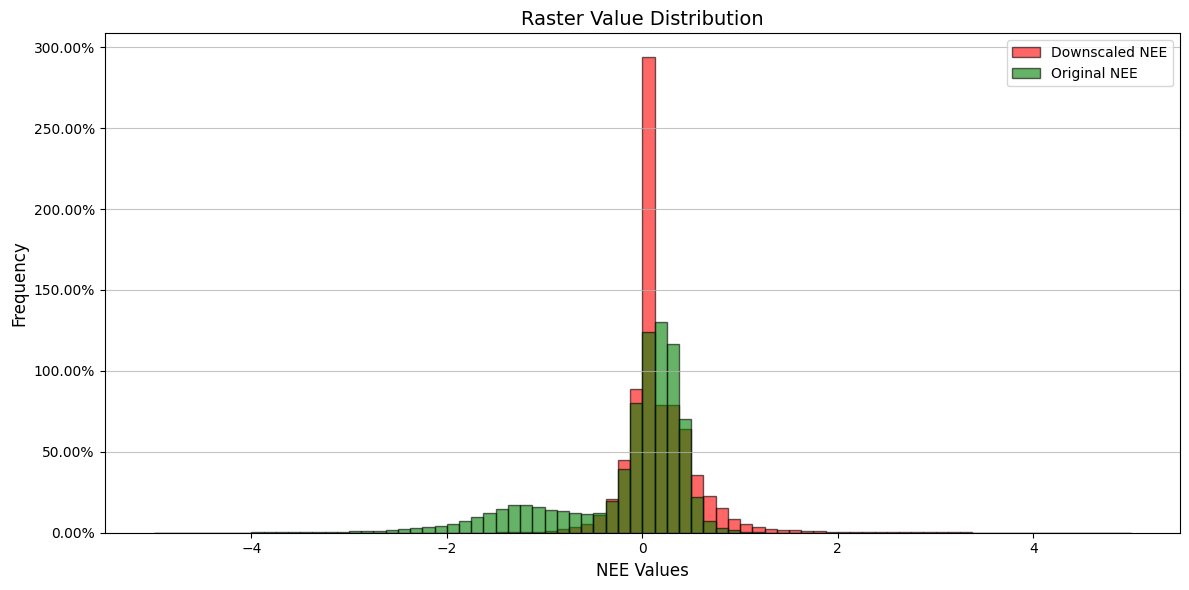

In [83]:

bins=80
title="Raster Value Distribution"
year_month = '200101'

downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
original_nee_file_path = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

with rasterio.open(downscaled_nee_file) as src:
    downscaled_nee = src.read(1)  # Read the first band
    downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee))]
valid_original = original_nee[(~np.isnan(original_nee))]

x_min = -5
x_max = 5

# Plot the pixel count histograms
plt.figure(figsize=(12, 6))
plt.hist(valid_downscaled, bins=bins, range=(x_min, x_max), density=True, color='red', alpha=0.6, edgecolor='black', label='Downscaled NEE')
plt.hist(valid_original, bins=bins, range=(x_min, x_max), density=True, color='green', alpha=0.6, edgecolor='black', label='Original NEE')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.2f}%')) # Convert density to percentage

plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

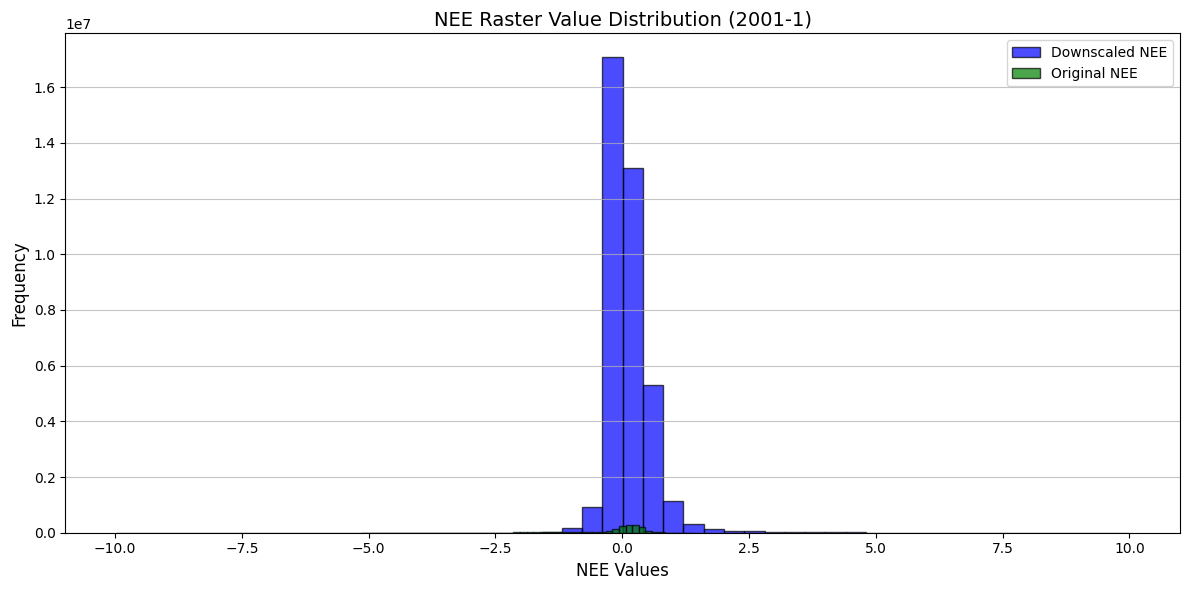

In [84]:


def plot_histogram_within_range(year_month, valid_values, bins=50, title="Raster Value Distribution"):
    """
    Plots a histogram of raster values within a specified range.

    Parameters:
        year_month(str): e.g. '200101'
        raster_file (str): Path to the raster file.
        value_range (tuple): Range of values to include in the histogram (min, max).
        bins (int): Number of bins for the histogram (default is 50).
        title (str): Title for the histogram plot.
        year (int): Year of the data.
        month (int): Month of the data.

    Returns:
        None: Displays the histogram.
    """
    
    downscaled_nee_file = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
    original_nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'

    with rasterio.open(downscaled_nee_file) as src:
        downscaled_nee = src.read(1)  # Read the first band
        downscaled_nee = np.where(raster_data == src.nodata, np.nan, raster_data)  # Replace nodata values with NaN

    variable = 'NEE'
    ds = xr.open_dataset(original_nee_file)
    original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

    min_val, max_val = value_range

    valid_downscaled = downscaled_nee[(~np.isnan(downscaled_nee)) & (downscaled_nee >= min_val) & (downscaled_nee <= max_val)]
    valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]

    # Plot the histograms
    plt.figure(figsize=(12, 6))
    plt.hist(valid_downscaled, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE')
    plt.hist(valid_original, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE')
    plt.title(title, fontsize=14)
    plt.xlabel('NEE Values', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
    
    # # Plot the histogram
    # plt.figure(figsize=(10, 6))
    # plt.hist(valid_values, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    # plt.title(title, fontsize=14)
    # plt.xlabel('Raster value', fontsize=12)
    # plt.ylabel('Pixel count', fontsize=12)
    # plt.grid(axis='y', alpha=0.75)
    # plt.tight_layout()
    # plt.show()

# year = 2001
# month = 1
year_month = '200101'
value_range = (-10, 10)  # Specify the range of values to include in the histogram
plot_histogram_within_range(year_month, valid_values, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")


In [85]:
max(valid_downscaled)

np.float32(54573.785)

In [86]:
# Plot the pixel percentage histograms

# raster_area_ratio = (len(downscaled_nee) * len(downscaled_nee[0])) / (len(original_nee) * len(original_nee[0]))
valid_downscaled_perc = valid_downscaled / (len(downscaled_nee) * len(downscaled_nee[0]))
# valid_original = original_nee[(~np.isnan(original_nee)) & (original_nee >= min_val) & (original_nee <= max_val)]
valid_original_perc = valid_original / (len(original_nee) * len(original_nee[0]))


plt.figure(figsize=(12, 12))
plt.hist(valid_downscaled_perc, bins=bins, color='blue', alpha=0.7, edgecolor='black', label='Downscaled NEE percentage')
plt.hist(valid_original_perc, bins=bins, color='green', alpha=0.7, edgecolor='black', label='Original NEE percentage')
plt.title(title, fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [42]:
valid_downscaled_perc

array([3.6241408e-09, 1.8559740e-09, 0.0000000e+00, ..., 1.5029079e-09,
       1.4759499e-09, 1.3613785e-09], dtype=float32)

In [38]:
print

9331200


In [39]:
print(len(downscaled_nee) * len(downscaled_nee[0]))

206291258


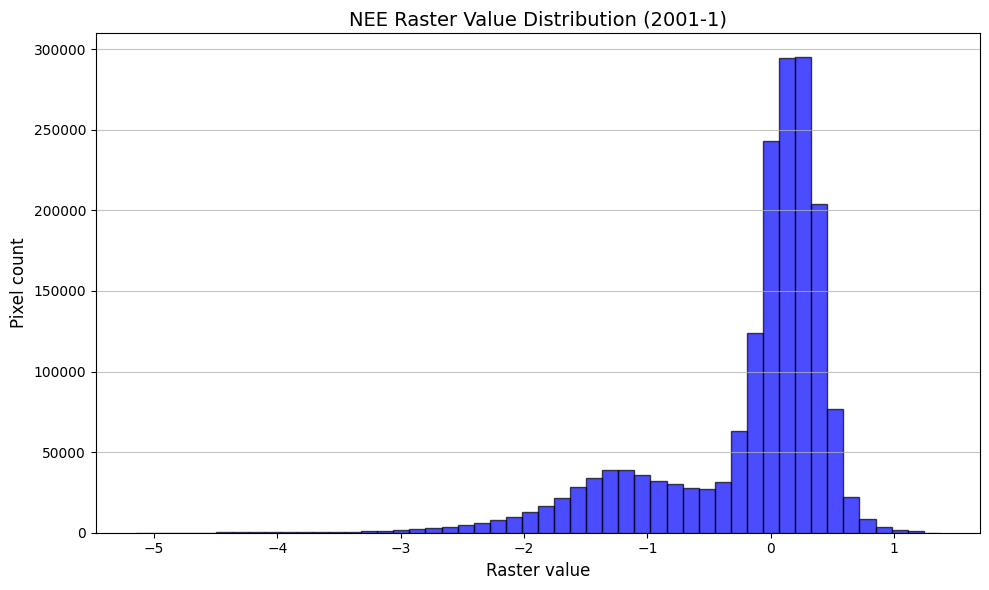

In [26]:
nee_raw_file = f"../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc"
plot_histogram_within_range(nee_raw_file, value_range, year, month, bins=50, title=f"NEE Raster Value Distribution ({str(year)}-{str(month)})")



In [ ]:


value_range = (-5, 5) 
plot_histogram_within_range(nee_raw_file, value_range, bins=50, title="NEE Raster Value Distribution (-10 to 50)")

In [ ]:
year_month = '200101'
downscaled_nee_file_path = f'../gis/output/downscaledNEE/downscaledNEE_US_{year_month}.tif'
with rasterio.open(downscaled_nee_file_path) as nee_dstrd:
    for index, record in msa_ds.iterrows():
        msa_name = record['NAMELSAD']
        # print(f'Generating downscaled data for {msa_name}...')
        msa = msa_ds.loc[[index]]

